In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Load data ---
df = pd.read_csv("20251003_flight_clean.csv", header=0)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')

# Set 'time' column as the index
df.set_index('time', inplace=True)

# Localize the naive datetime to UTC first  
# df.index = df.index.tz_localize('UTC').tz_convert('America/Los_Angeles')

# Ensure that longitude values are negative
df['lon'] = -df['lon']

def convert_to_decimal_degrees(coord):
    degrees = int(coord)  # Extract degrees (integer part)
    minutes = abs(coord - degrees) * 100  # Extract the minutes
    decimal_degrees = abs(degrees) + minutes / 60  # Convert minutes to decimal and add to degrees
    return decimal_degrees if coord >= 0 else -decimal_degrees  # Keep the sign for negative coordinates

# Apply the conversion function to the lat and lon columns
df['lat_decimal'] = df['lat'].apply(convert_to_decimal_degrees)
df['lon_decimal'] = df['lon'].apply(convert_to_decimal_degrees)

# print(df[['lat_decimal', 'lon_decimal']])

takeoff_all   = df[0:1470]
takeoff       = df[0:600]
landing_all   = df[2500:3855]
landing       = df[3400:3855]


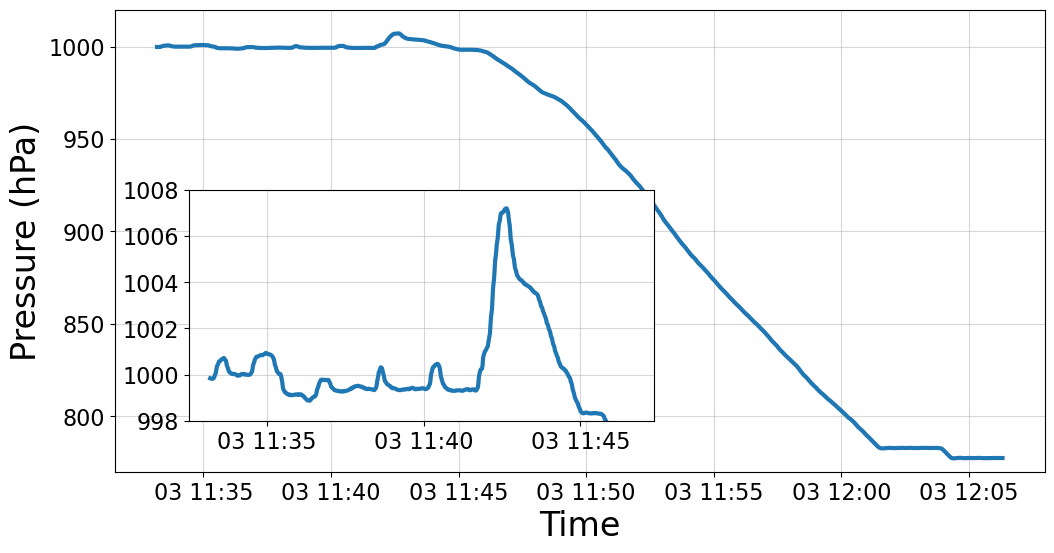

In [ ]:
# --- Main plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(takeoff_all.index, takeoff_all["pressurehPa"], label="Pressure", lw=3)

# --- Labels and formatting ---
# ax.set_title("Pressure (hPa) During Takeoff", fontsize=24)
ax.set_xlabel("Time", fontsize=24)
ax.set_ylabel("Pressure (hPa)", fontsize=24)
ax.set_ylim(770, 1020)
ax.grid(alpha=0.5)
# ax.legend(loc="lower left", markerscale=10)
ax.tick_params(axis="both", labelsize=16)

# --- Inset plot (zoom on 900–1000) ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower left",
    borderpad=2,
    bbox_to_anchor=(0.05, 0.05, 1, 1),  # move right and up
    bbox_transform=ax.transAxes,
)
axins.plot(takeoff.index, takeoff["pressurehPa"], color="tab:blue", lw=3)
# axins.set_xlim(850, 100)
axins.set_ylim(998,1008)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)  # inset ticks

plt.show()

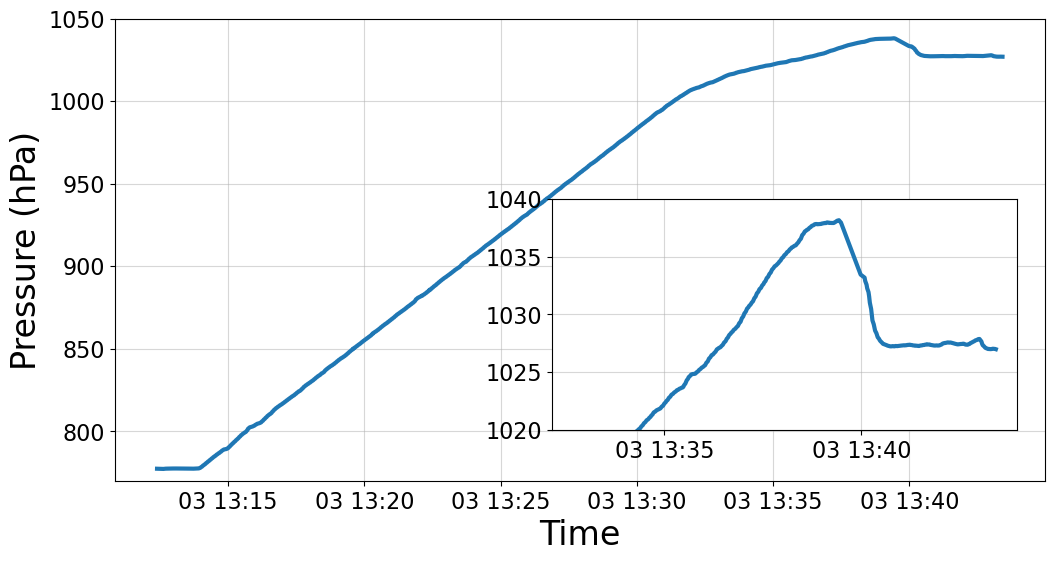

In [ ]:
# --- Main plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(landing_all.index, landing_all["pressurehPa"], label="Pressure", lw=3)

# --- Labels and formatting ---
# ax.set_title("Pressure (hPa) During Takeoff", fontsize=24)
ax.set_xlabel("Time", fontsize=24)
ax.set_ylabel("Pressure (hPa)", fontsize=24)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
# ax.legend(loc="lower left", markerscale=10)
ax.tick_params(axis="both", labelsize=16)

# --- Inset plot (zoom on 900–1000) ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower right",
    borderpad=2,
    bbox_to_anchor=(0, 0.05, 1, 1), 
    bbox_transform=ax.transAxes,
)
axins.plot(landing.index, landing["pressurehPa"], color="tab:blue", lw=3)
# axins.set_xlim(850, 100)
axins.set_ylim(1020,1040)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)  # inset ticks

plt.show()

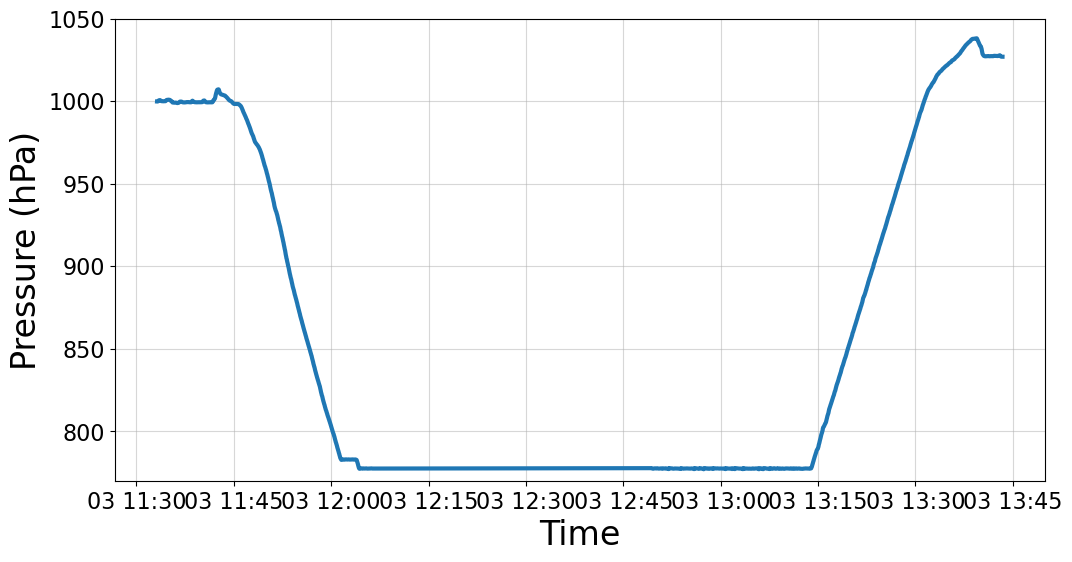

In [ ]:
# --- Main plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df["pressurehPa"], label="Pressure", lw=3)

# --- Labels and formatting ---
ax.set_xlabel("Time", fontsize=24)
ax.set_ylabel("Pressure (hPa)", fontsize=24)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

plt.show()

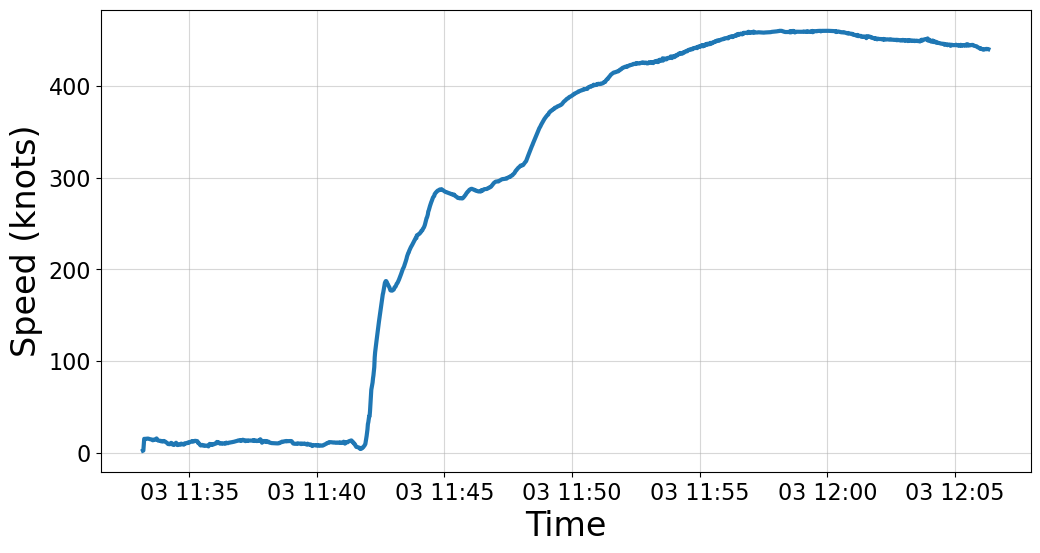

In [35]:
# --- Main plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(takeoff_all.index, takeoff_all["speed"], label="Speed", lw=3)

# --- Labels and formatting ---
ax.set_xlabel("Time", fontsize=24)
ax.set_ylabel("Speed (knots)", fontsize=24)
# ax.set_ylim(770, 1020)
ax.grid(alpha=0.5)
# ax.legend(loc="lower left", markerscale=10)
ax.tick_params(axis="both", labelsize=16)


plt.show()

In [2]:
import folium 

# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20251003_flight.html')


C:\Users\sscop\AppData\Local\Temp\ipykernel_23020\2520031456.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


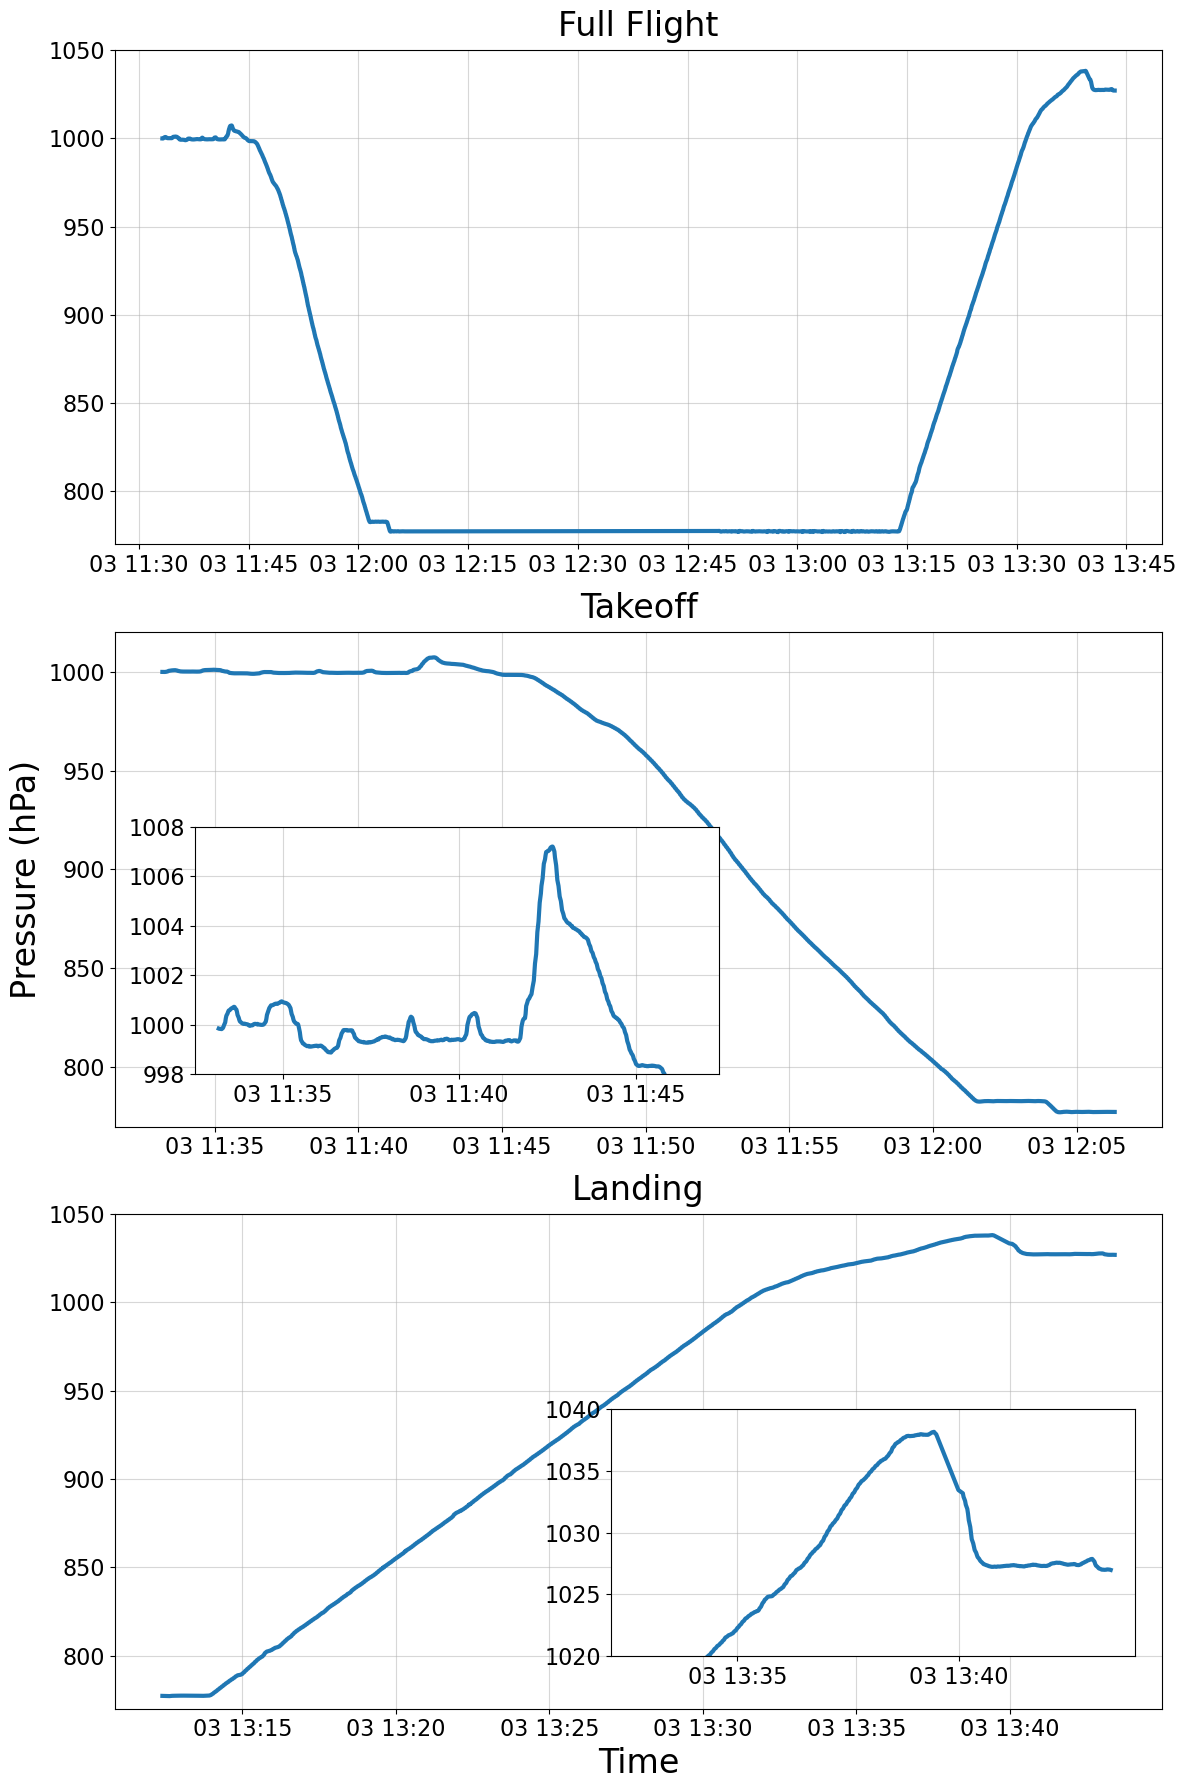

In [61]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)

# === 1) Full Flight ===
ax = axes[0]
ax.plot(df.index, df["pressurehPa"], lw=3)
ax.set_title("Full Flight", fontsize=24, pad=10)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# === 2) Takeoff ===
ax = axes[1]
ax.plot(takeoff_all.index, takeoff_all["pressurehPa"], lw=3)
ax.set_title("Takeoff", fontsize=24, pad=10)
ax.set_ylabel("Pressure (hPa)", fontsize=24)
ax.set_ylim(770, 1020)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# --- Inset for takeoff ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower left",
    borderpad=2,
    bbox_to_anchor=(0.05, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
)
axins.plot(takeoff.index, takeoff["pressurehPa"], color="tab:blue", lw=3)
axins.set_ylim(998, 1008)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)

# === 3) Landing ===
ax = axes[2]
ax.plot(landing_all.index, landing_all["pressurehPa"], lw=3)
ax.set_title("Landing", fontsize=24, pad=10)
ax.set_xlabel("Time", fontsize=24)
ax.set_ylim(770, 1050)
ax.grid(alpha=0.5)
ax.tick_params(axis="both", labelsize=16)

# --- Inset for landing ---
axins = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc="lower right",
    borderpad=2,
    bbox_to_anchor=(0, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
)
axins.plot(landing.index, landing["pressurehPa"], color="tab:blue", lw=3)
axins.set_ylim(1020, 1040)
axins.grid(alpha=0.5)
axins.tick_params(axis="both", labelsize=16)

plt.tight_layout()
plt.show()
